In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)

In [2]:
nabil = pd.read_csv("companies/NABIL.csv")
nica = pd.read_csv("companies/NICA.csv")
hidcl = pd.read_csv("companies/HIDCL.csv")
sicl = pd.read_csv("companies/SICL.csv")

In [3]:
nabil["Company"] = "NABIL"
nica["Company"] = "NICA"
hidcl["Company"] = "HIDCL"
sicl["Company"] = "SICL"

In [4]:
df = pd.concat(
    [nabil, nica, hidcl, sicl],
    ignore_index=True
)

print(df.shape)
df.head()

(10870, 25)


,Symbol,Date,Open,High,Low,Close,Percent Change,Volume,Turnover,Daily_Return,...,RSI_14,MACD,MACD_Signal,ATR_14,BB_Middle,BB_Std,BB_Upper,BB_Lower,OBV,Company
0,NABIL,2012-01-01,873.0,879.0,851.0,879.0,0.69%,799.0,684720.0,NaN,...,30.121017,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NABIL
1,NABIL,2012-01-02,879.0,913.0,882.0,900.0,2.39%,1002.0,897160.0,0.023891,...,45.277036,1.675214,0.335043,NaN,NaN,NaN,NaN,NaN,1002.0,NABIL
2,NABIL,2012-01-03,900.0,916.0,892.0,892.0,-0.89%,2653.0,2396445.0,-0.008889,...,46.503257,2.330436,0.734121,NaN,NaN,NaN,NaN,NaN,-1651.0,NABIL
3,NABIL,2012-01-04,892.0,875.0,842.0,865.0,-3.03%,490.0,417289.0,-0.030269,...,46.864743,0.663382,0.719974,NaN,NaN,NaN,NaN,NaN,-2141.0,NABIL
4,NABIL,2012-01-05,865.0,875.0,858.0,858.0,-0.81%,121.0,104175.0,-0.008092,...,46.615120,-1.208678,0.334243,NaN,NaN,NaN,NaN,NaN,-2262.0,NABIL


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10870 entries, 0 to 10869
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          10870 non-null  str    
 1   Date            10870 non-null  str    
 2   Open            10870 non-null  float64
 3   High            10870 non-null  float64
 4   Low             10870 non-null  float64
 5   Close           10870 non-null  float64
 6   Percent Change  10870 non-null  str    
 7   Volume          10870 non-null  float64
 8   Turnover        10870 non-null  float64
 9   Daily_Return    10866 non-null  float64
 10  Log_Return      10866 non-null  float64
 11  SMA_5           10854 non-null  float64
 12  SMA_20          10794 non-null  float64
 13  EMA_12          10870 non-null  float64
 14  EMA_26          10870 non-null  float64
 15  RSI_14          10818 non-null  float64
 16  MACD            10870 non-null  float64
 17  MACD_Signal     10870 non-null  float64
 1

In [6]:
df.describe()

,Open,High,Low,Close,Volume,Turnover,Daily_Return,Log_Return,SMA_5,SMA_20,...,EMA_26,RSI_14,MACD,MACD_Signal,ATR_14,BB_Middle,BB_Std,BB_Upper,BB_Lower,OBV
count,10870.000000,10870.000000,10870.000000,10870.000000,1.087000e+04,1.087000e+04,10866.000000,10866.000000,10854.000000,10794.000000,...,10870.000000,10818.000000,10870.000000,10870.000000,10818.000000,10794.000000,10794.000000,10794.000000,10794.000000,1.087000e+04
mean,870.426697,881.646304,857.748757,869.235190,5.288910e+04,3.139294e+07,0.000283,-0.000038,869.802597,871.781008,...,869.330269,48.314152,-0.033961,-0.024256,26.371720,871.781008,36.706317,945.193642,798.368375,1.282505e+06
std,647.328857,656.207320,637.935083,647.475058,1.127858e+05,6.131955e+07,0.024916,0.025631,647.057893,645.853145,...,641.430896,19.379236,40.329690,38.254839,25.167043,645.853145,51.459741,715.923817,585.568525,3.594477e+06
min,0.000000,122.000000,116.000000,118.000000,1.000000e+01,1.330000e+03,-0.399722,-0.510363,123.000000,128.250000,...,129.232161,0.000000,-458.238634,-419.437820,2.785714,128.250000,0.994723,130.589446,116.297480,-7.604348e+06
25%,408.450000,413.125000,402.850000,407.000000,4.454000e+03,2.770132e+06,-0.010256,-0.010309,408.556500,410.100000,...,405.031228,34.356660,-10.563100,-10.404799,11.000000,410.100000,10.159943,445.140333,374.019133,6.399250e+03
50%,745.000000,754.000000,735.000000,743.000000,1.448050e+04,9.870514e+06,-0.001068,-0.001068,745.100000,751.090000,...,754.485399,47.756030,-1.463340,-1.477848,18.682143,751.090000,20.013546,793.067711,695.401025,4.002170e+05
75%,1037.000000,1050.750000,1020.000000,1035.000000,5.471550e+04,3.240892e+07,0.008696,0.008658,1035.100000,1039.621250,...,1031.532594,62.274769,8.981481,8.834984,32.214286,1039.621250,42.974303,1145.900424,939.526431,1.294345e+06
max,4305.000000,4320.000000,4200.000000,4300.000000,2.109907e+06,1.240625e+09,0.102439,0.097525,4222.800000,4108.050000,...,3999.606690,100.000000,281.939592,259.293756,294.714286,4108.050000,744.930973,4622.526764,3909.371762,1.643866e+07


In [7]:
df.columns

Index(['Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Percent Change',
       'Volume', 'Turnover', 'Daily_Return', 'Log_Return', 'SMA_5', 'SMA_20',
       'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'ATR_14',
       'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'OBV', 'Company'],
      dtype='str')

In [8]:
df.isnull().sum()

Symbol             0
Date               0
Open               0
High               0
Low                0
Close              0
Percent Change     0
Volume             0
Turnover           0
Daily_Return       4
Log_Return         4
SMA_5             16
SMA_20            76
EMA_12             0
EMA_26             0
RSI_14            52
MACD               0
MACD_Signal        0
ATR_14            52
BB_Middle         76
BB_Std            76
BB_Upper          76
BB_Lower          76
OBV                0
Company            0
dtype: int64

In [9]:
df_clean = df.dropna().reset_index(drop=True)

In [10]:
df_clean.isnull().sum()

Symbol            0
Date              0
Open              0
High              0
Low               0
Close             0
Percent Change    0
Volume            0
Turnover          0
Daily_Return      0
Log_Return        0
SMA_5             0
SMA_20            0
EMA_12            0
EMA_26            0
RSI_14            0
MACD              0
MACD_Signal       0
ATR_14            0
BB_Middle         0
BB_Std            0
BB_Upper          0
BB_Lower          0
OBV               0
Company           0
dtype: int64

In [11]:
print(df_clean.columns)

Index(['Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Percent Change',
       'Volume', 'Turnover', 'Daily_Return', 'Log_Return', 'SMA_5', 'SMA_20',
       'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'ATR_14',
       'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'OBV', 'Company'],
      dtype='str')


Check Duplicates

In [12]:
df_clean.duplicated().sum()

np.int64(0)

In [13]:
df_clean.drop_duplicates(inplace=True)

Convert Date

In [14]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

In [15]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10742 entries, 0 to 10741
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Symbol          10742 non-null  str           
 1   Date            10742 non-null  datetime64[us]
 2   Open            10742 non-null  float64       
 3   High            10742 non-null  float64       
 4   Low             10742 non-null  float64       
 5   Close           10742 non-null  float64       
 6   Percent Change  10742 non-null  str           
 7   Volume          10742 non-null  float64       
 8   Turnover        10742 non-null  float64       
 9   Daily_Return    10742 non-null  float64       
 10  Log_Return      10742 non-null  float64       
 11  SMA_5           10742 non-null  float64       
 12  SMA_20          10742 non-null  float64       
 13  EMA_12          10742 non-null  float64       
 14  EMA_26          10742 non-null  float64       
 15  RSI_14       

EDA

In [16]:
df_clean.describe()

,Date,Open,High,Low,Close,Volume,Turnover,Daily_Return,Log_Return,SMA_5,...,EMA_26,RSI_14,MACD,MACD_Signal,ATR_14,BB_Middle,BB_Std,BB_Upper,BB_Lower,OBV
count,10742,10742.000000,10742.000000,10742.000000,10742.000000,1.074200e+04,1.074200e+04,10742.000000,10742.000000,10742.000000,...,10742.000000,10742.000000,10742.000000,10742.000000,10742.000000,10742.000000,10742.000000,10742.000000,10742.000000,1.074200e+04
mean,2019-07-31 13:22:42.651275,874.649025,885.894724,861.931679,873.437999,5.306060e+04,3.158057e+07,0.000291,-0.000027,873.484310,...,873.663599,48.439420,-0.096607,-0.071809,26.450778,873.676388,36.834656,947.345700,800.007076,1.297935e+06
min,2012-02-01 00:00:00,120.000000,122.000000,116.000000,118.000000,1.000000e+01,1.330000e+03,-0.399722,-0.510363,123.000000,...,129.232161,0.000000,-458.238634,-419.437820,2.785714,128.250000,0.994723,130.589446,116.297480,-7.604348e+06
25%,2016-10-16 00:00:00,410.225000,415.000000,405.000000,410.000000,4.469500e+03,2.807606e+06,-0.010212,-0.010265,410.340000,...,409.867297,34.482759,-10.725066,-10.507110,11.021429,411.521250,10.202371,446.819546,375.156511,9.698000e+03
50%,2019-08-21 00:00:00,749.000000,757.000000,739.000000,747.000000,1.449000e+04,9.891180e+06,-0.001025,-0.001026,748.320000,...,757.448893,47.936014,-1.473903,-1.490583,18.760714,753.267500,20.135266,795.004291,696.484883,4.062000e+05
75%,2022-08-23 18:00:00,1050.000000,1066.000000,1034.750000,1045.000000,5.477800e+04,3.261052e+07,0.008696,0.008658,1047.190000,...,1048.641292,62.375613,8.996088,8.856992,32.314286,1048.401250,43.113000,1156.193061,943.531797,1.324964e+06
max,2025-08-21 00:00:00,4305.000000,4320.000000,4200.000000,4300.000000,2.109907e+06,1.240625e+09,0.102439,0.097525,4222.800000,...,3999.606690,100.000000,281.939592,259.293756,294.714286,4108.050000,744.930973,4622.526764,3909.371762,1.643866e+07
std,NaN,649.539808,658.492758,640.124595,649.721607,1.132751e+05,6.161156e+07,0.024783,0.025516,649.032636,...,643.569181,19.363627,40.512527,38.442216,25.226647,646.721716,51.549763,716.876519,586.383013,3.574169e+06


In [17]:
df_clean["Company"].value_counts()

Company
NABIL    3096
SICL     2829
NICA     2746
HIDCL    2071
Name: count, dtype: int64

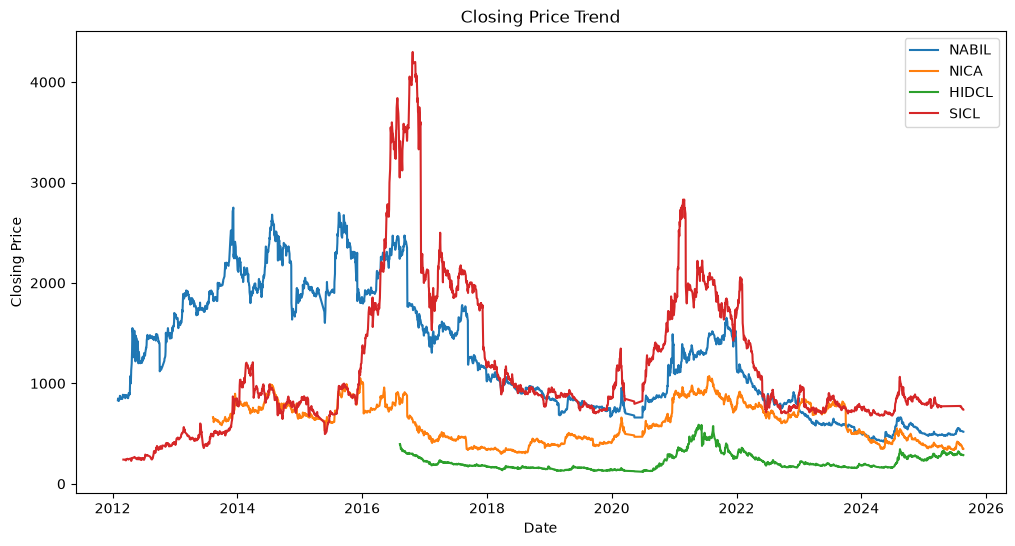

In [18]:
plt.figure(figsize=(12,6))

for company in df_clean["Company"].unique():
    temp = df_clean[df_clean["Company"] == company]
    plt.plot(temp["Date"], temp["Close"], label=company)

plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

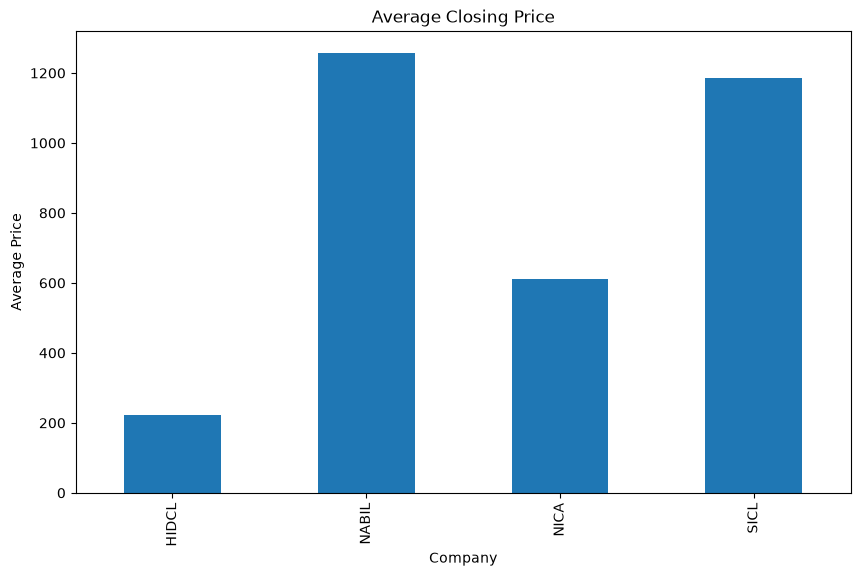

In [19]:
avg = df_clean.groupby("Company")["Close"].mean()

avg.plot(kind="bar")

plt.title("Average Closing Price")
plt.ylabel("Average Price")

plt.show()

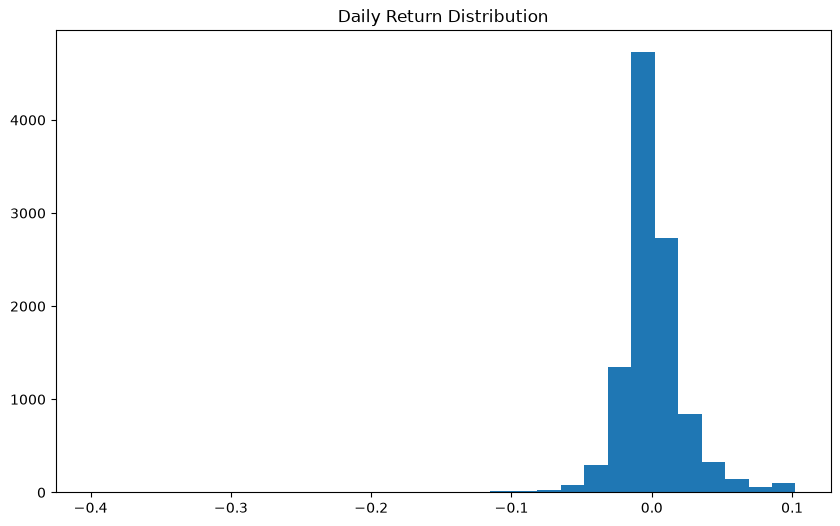

In [20]:
plt.hist(df_clean["Daily_Return"], bins=30)

plt.title("Daily Return Distribution")

plt.show()

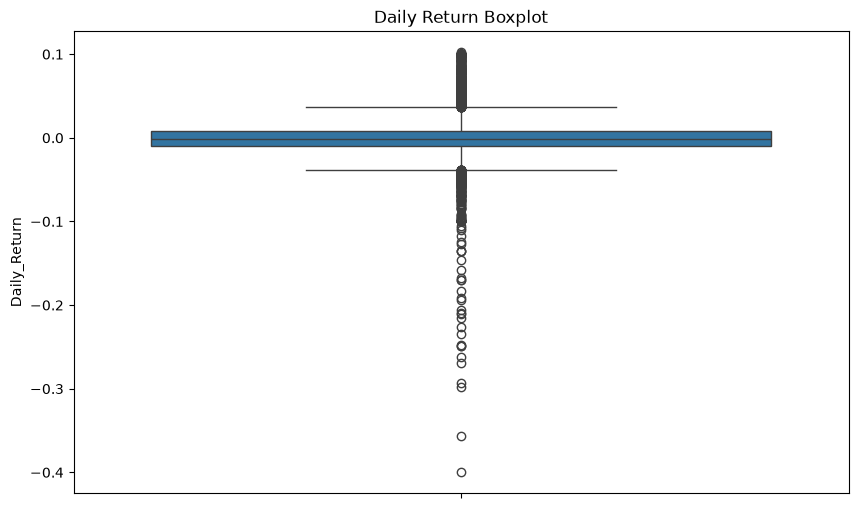

In [21]:
sns.boxplot(y=df_clean["Daily_Return"])

plt.title("Daily Return Boxplot")

plt.show()

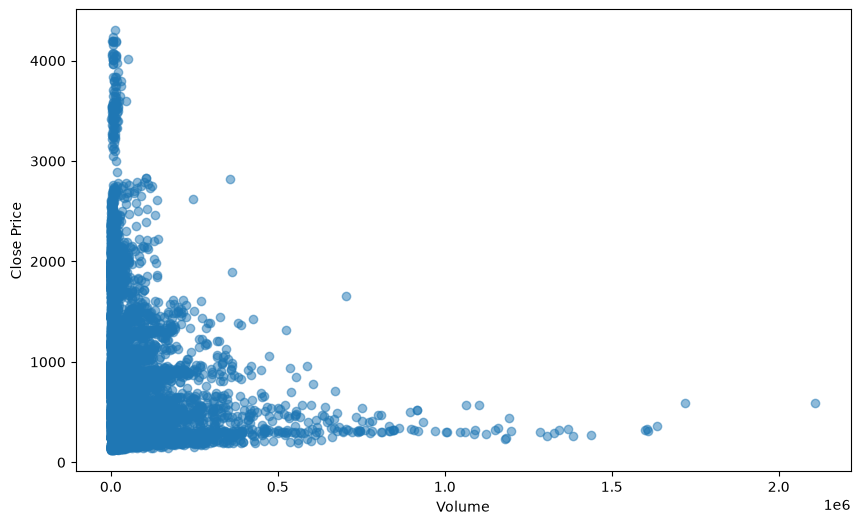

In [22]:
plt.scatter(
    df_clean["Volume"],
    df_clean["Close"],
    alpha=0.5
)

plt.xlabel("Volume")
plt.ylabel("Close Price")

plt.show()

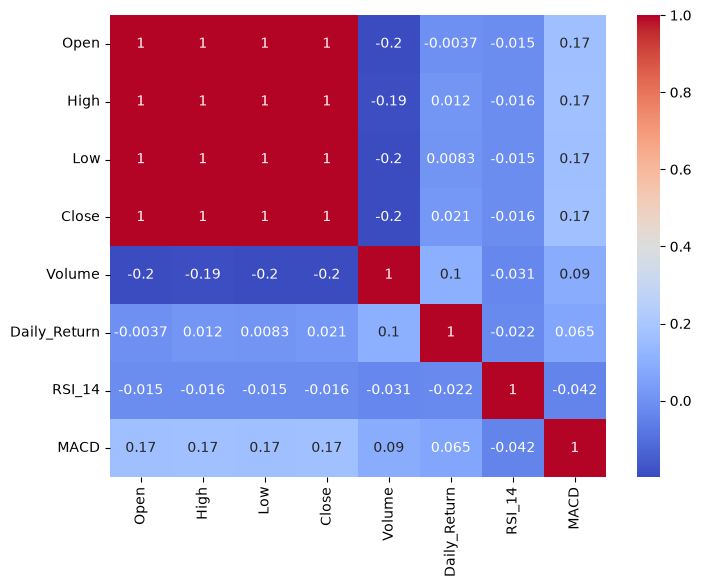

In [23]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "RSI_14",
    "MACD"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df_clean[features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

week4

In [24]:
# Sort by company and date
df_clean = df_clean.sort_values(["Company", "Date"]).reset_index(drop=True)

# Create next day's closing price
df_clean["Next_Close"] = df_clean.groupby("Company")["Close"].shift(-1)

# Remove rows without a next day
df_clean = df_clean.dropna(subset=["Next_Close"])

# Create movement target
df_clean["Movement"] = (df_clean["Next_Close"] > df_clean["Close"]).astype(int)

# Remove helper column
df_clean.drop(columns=["Next_Close"], inplace=True)

# Check
print(df_clean[["Company", "Date", "Close", "Movement"]].head())

  Company       Date  Close  Movement
0   HIDCL 2016-08-09  395.0         0
1   HIDCL 2016-08-10  388.0         1
2   HIDCL 2016-08-11  390.0         0
3   HIDCL 2016-08-14  362.0         0
4   HIDCL 2016-08-15  344.0         1


In [25]:
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "Daily_Return",
    "RSI_14",
    "MACD",
    "SMA_5",
    "SMA_20"
]

X = df_clean[features]
y = df_clean["Movement"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.5772811918063314

Confusion Matrix
[[1205   29]
 [ 879   35]]

Classification Report
              precision    recall  f1-score   support

           0       0.58      0.98      0.73      1234
           1       0.55      0.04      0.07       914

    accuracy                           0.58      2148
   macro avg       0.56      0.51      0.40      2148
weighted avg       0.56      0.58      0.45      2148



In [31]:
df_clean.to_csv("companies/NEPSE_Cleaned.csv", index=False)

In [32]:
df_clean.head()

,Symbol,Date,Open,High,Low,Close,Percent Change,Volume,Turnover,Daily_Return,...,MACD,MACD_Signal,ATR_14,BB_Middle,BB_Std,BB_Upper,BB_Lower,OBV,Company,Movement
0,HIDCL,2016-08-09,376.0,397.0,376.0,395.0,7.05 %,16573.0,6415360.0,0.070461,...,2.449412,8.365165,20.428571,411.40,27.073778,465.547557,357.252443,56380.0,HIDCL,0
1,HIDCL,2016-08-10,400.0,402.0,385.0,388.0,-1.77 %,44128.0,17307700.0,-0.017722,...,1.422628,6.976657,19.357143,412.85,24.800838,462.451677,363.248323,12252.0,HIDCL,1
2,HIDCL,2016-08-11,390.0,392.0,383.0,390.0,-0.51 %,34904.0,13512900.0,0.005155,...,0.761498,5.733626,17.857143,412.65,24.976357,462.602714,362.697286,47156.0,HIDCL,0
3,HIDCL,2016-08-14,385.0,390.0,358.0,362.0,-7.18 %,49307.0,18049000.0,-0.071795,...,-1.998777,4.187145,18.214286,409.10,26.903140,462.906280,355.293720,-2151.0,HIDCL,0
4,HIDCL,2016-08-15,366.0,366.0,338.0,344.0,-4.97 %,36829.0,12687900.0,-0.049724,...,-5.574504,2.234815,18.285714,402.50,25.795756,454.091513,350.908487,-38980.0,HIDCL,1


In [33]:
df_clean[[
    "Open",
    "High",
    "Low",
    "Volume",
    "Daily_Return",
    "RSI_14",
    "MACD",
    "SMA_5",
    "SMA_20"
]].head(10)

,Open,High,Low,Volume,Daily_Return,RSI_14,MACD,SMA_5,SMA_20
0,376.0,397.0,376.0,16573.0,0.070461,16.081648,2.449412,389.6,411.40
1,400.0,402.0,385.0,44128.0,-0.017722,17.218668,1.422628,386.6,412.85
2,390.0,392.0,383.0,34904.0,0.005155,33.885932,0.761498,386.4,412.65
3,385.0,390.0,358.0,49307.0,-0.071795,39.504396,-1.998777,380.8,409.10
4,366.0,366.0,338.0,36829.0,-0.049724,37.017310,-5.574504,375.8,402.50
5,338.0,355.0,336.0,36420.0,0.017442,47.993403,-7.833841,366.8,397.25
6,350.0,357.0,345.0,33053.0,0.014286,52.119403,-9.115842,360.2,393.65
7,355.0,356.0,344.0,14759.0,-0.025352,53.761891,-10.734323,351.4,390.95
8,340.0,341.0,326.0,30973.0,-0.049133,52.855321,-13.236160,344.8,386.90
9,325.0,330.0,319.0,29800.0,-0.012158,57.854821,-15.364538,341.0,381.65
